<a href="https://colab.research.google.com/github/fatiyaqurrotuaini47-beep/UTS_FATIYAQURROTU-AINI/blob/main/UTS_NLP_FATIYAQA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Metode Embedding (Word2Vec)

In [60]:
!pip install nltk

In [61]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [62]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [63]:
pip install Sastrawi

In [64]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

!pip install gensim
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
file_path = '/content/drive/MyDrive/UTS_NLP/Fake.csv'
df = pd.read_csv(file_path)
df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [58]:
print("Nama kolom pada dataset:")
print(df.columns.tolist())

Nama kolom pada dataset:
['title', 'text', 'subject', 'date']


MEMILIH KOLOM TEKS

In [59]:
possible_text_cols = ['text']  # fokus ke text utama

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

print("Kolom teks yang digunakan:", text_col)

Kolom teks yang digunakan: text


CLEANING TEXT

In [65]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump just couldn t wish all americans ...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",on friday it was revealed that former milwauke...
3,"On Christmas day, Donald Trump announced that ...",on christmas day donald trump announced that h...
4,Pope Francis used his annual Christmas Day mes...,pope francis used his annual christmas day mes...


TOKENIZATION

In [66]:
df['tokens'] = df['clean_text'].apply(word_tokenize)
df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,donald trump just couldn t wish all americans ...,"[donald, trump, just, couldn, t, wish, all, am..."
1,house intelligence committee chairman devin nu...,"[house, intelligence, committee, chairman, dev..."
2,on friday it was revealed that former milwauke...,"[on, friday, it, was, revealed, that, former, ..."
3,on christmas day donald trump announced that h...,"[on, christmas, day, donald, trump, announced,..."
4,pope francis used his annual christmas day mes...,"[pope, francis, used, his, annual, christmas, ..."


STOPWORD REMOVAL (ENGLISH)

In [67]:
stop_words = set(stopwords.words('english'))

df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words and len(word) > 2]
)

df[['tokens', 'tokens_no_stopwords']].head()

,tokens,tokens_no_stopwords
0,"[donald, trump, just, couldn, t, wish, all, am...","[donald, trump, wish, americans, happy, new, y..."
1,"[house, intelligence, committee, chairman, dev...","[house, intelligence, committee, chairman, dev..."
2,"[on, friday, it, was, revealed, that, former, ...","[friday, revealed, former, milwaukee, sheriff,..."
3,"[on, christmas, day, donald, trump, announced,...","[christmas, day, donald, trump, announced, wou..."
4,"[pope, francis, used, his, annual, christmas, ...","[pope, francis, used, annual, christmas, day, ..."


NORMALIZATION (DIKOSONGKAN BIAR STRUKTUR SAMA)

In [68]:
# Tidak digunakan untuk dataset ini (bahasa formal)

def normalize_tokens(tokens):
    return tokens

df['tokens_normalized'] = df['tokens_no_stopwords'].apply(normalize_tokens)
df[['tokens_no_stopwords', 'tokens_normalized']].head(15)

,tokens_no_stopwords,tokens_normalized
0,"[donald, trump, wish, americans, happy, new, y...","[donald, trump, wish, americans, happy, new, y..."
1,"[house, intelligence, committee, chairman, dev...","[house, intelligence, committee, chairman, dev..."
2,"[friday, revealed, former, milwaukee, sheriff,...","[friday, revealed, former, milwaukee, sheriff,..."
3,"[christmas, day, donald, trump, announced, wou...","[christmas, day, donald, trump, announced, wou..."
4,"[pope, francis, used, annual, christmas, day, ...","[pope, francis, used, annual, christmas, day, ..."
5,"[number, cases, cops, brutalizing, killing, pe...","[number, cases, cops, brutalizing, killing, pe..."
6,"[donald, trump, spent, good, portion, day, gol...","[donald, trump, spent, good, portion, day, gol..."
7,"[wake, yet, another, court, decision, derailed...","[wake, yet, another, court, decision, derailed..."
8,"[many, people, raised, alarm, regarding, fact,...","[many, people, raised, alarm, regarding, fact,..."
9,"[might, thought, get, break, watching, people,...","[might, thought, get, break, watching, people,..."


MENGHAPUS BARIS KOSONG

In [69]:
df = df[df['tokens_normalized'].apply(len) > 0].reset_index(drop=True)
print("Jumlah data setelah preprocessing:", len(df))
df.head()

Jumlah data setelah preprocessing: 22766


,title,text,subject,date,clean_text,tokens,tokens_no_stopwords,tokens_normalized
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",donald trump just couldn t wish all americans ...,"[donald, trump, just, couldn, t, wish, all, am...","[donald, trump, wish, americans, happy, new, y...","[donald, trump, wish, americans, happy, new, y..."
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",house intelligence committee chairman devin nu...,"[house, intelligence, committee, chairman, dev...","[house, intelligence, committee, chairman, dev...","[house, intelligence, committee, chairman, dev..."
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",on friday it was revealed that former milwauke...,"[on, friday, it, was, revealed, that, former, ...","[friday, revealed, former, milwaukee, sheriff,...","[friday, revealed, former, milwaukee, sheriff,..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",on christmas day donald trump announced that h...,"[on, christmas, day, donald, trump, announced,...","[christmas, day, donald, trump, announced, wou...","[christmas, day, donald, trump, announced, wou..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",pope francis used his annual christmas day mes...,"[pope, francis, used, his, annual, christmas, ...","[pope, francis, used, annual, christmas, day, ...","[pope, francis, used, annual, christmas, day, ..."


MEMBUAT MODEL WORD2VEC

In [70]:
# WAJIB ADA (perbaikan dari kode kamu)
sentences = df['tokens_normalized'].tolist()

model_w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1
)

print("Model Word2Vec berhasil dibuat")

Model Word2Vec berhasil dibuat


MELIHAT VOCABULARY

In [71]:
vocab = list(model_w2v.wv.index_to_key)
print("Jumlah vocabulary:", len(vocab))
print("20 kata pertama:", vocab[:20])

Jumlah vocabulary: 33907
20 kata pertama: ['trump', 'said', 'president', 'people', 'one', 'would', 'clinton', 'obama', 'like', 'donald', 'also', 'news', 'new', 'hillary', 'even', 'time', 'state', 'white', 'via', 'media']


MENCARI KATA MIRIP

In [72]:
kata_uji = ['trump', 'government', 'media', 'president', 'news']

for kata in kata_uji:
    if kata in model_w2v.wv:
        print(f"\nKata yang mirip dengan '{kata}':")
        print(model_w2v.wv.most_similar(kata, topn=5))
    else:
        print(f"\nKata '{kata}' tidak ditemukan dalam vocabulary.")


Kata yang mirip dengan 'trump':
[('donald', 0.8661913871765137), ('elect', 0.7411747574806213), ('henchmen', 0.7121812701225281), ('flirted', 0.6992058753967285), ('donaldjtrumpjr', 0.6966161131858826)]

Kata yang mirip dengan 'government':
[('bureaucrats', 0.655407726764679), ('militarize', 0.65512615442276), ('monies', 0.6505336165428162), ('classifies', 0.6494084596633911), ('benefactors', 0.6486074328422546)]

Kata yang mirip dengan 'media':
[('mainstream', 0.8178622126579285), ('outlets', 0.7802477478981018), ('critiques', 0.6704117655754089), ('reportage', 0.6644625067710876), ('gatekeepers', 0.6603402495384216)]

Kata yang mirip dengan 'president':
[('barack', 0.6971444487571716), ('macri', 0.6903543472290039), ('inaugurated', 0.6702609062194824), ('elect', 0.6680871248245239), ('administration', 0.6632851958274841)]

Kata yang mirip dengan 'news':
[('newsread', 0.7303588390350342), ('newswe', 0.7136627435684204), ('newswatch', 0.7090414762496948), ('zerohedgeread', 0.704571723

MELIHAT VEKTOR KATA

In [73]:
if 'trump' in model_w2v.wv:
    print(model_w2v.wv['trump'][:10])
else:
    print("Kata tidak ditemukan dalam model.")

[ 0.34660086  0.03560524 -0.02486676  0.1555775  -0.08702204 -0.12409503
 -0.29086617  0.5316245   0.21737471 -0.15755361]


VEKTOR DOKUMEN

In [74]:
def document_vector(tokens, model):
    valid_words = [word for word in tokens if word in model.wv]
    if len(valid_words) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[valid_words], axis=0)

df['doc_vector'] = df['tokens_normalized'].apply(lambda x: document_vector(x, model_w2v))
df[['tokens_normalized', 'doc_vector']].head()

,tokens_normalized,doc_vector
0,"[donald, trump, wish, americans, happy, new, y...","[-0.0002921059, 0.26771888, -0.016820474, 0.14..."
1,"[house, intelligence, committee, chairman, dev...","[0.052344985, 0.2103783, 0.018435193, 0.020021..."
2,"[friday, revealed, former, milwaukee, sheriff,...","[0.010971971, 0.22489166, -0.030896146, 0.0518..."
3,"[christmas, day, donald, trump, announced, wou...","[0.020598523, 0.23563771, -0.0102186045, 0.068..."
4,"[pope, francis, used, annual, christmas, day, ...","[0.004691145, 0.21062095, 0.06263682, 0.106201..."


VISUALISASI FREKUENSI

In [ ]:
import matplotlib.pyplot as plt

words_to_plot = vocab[:20]

counts = []
for word in words_to_plot:
    total = sum(tokens.count(word) for tokens in df['tokens_normalized'])
    counts.append(total)

plt.figure(figsize=(12, 6))
plt.bar(words_to_plot, counts)
plt.xticks(rotation=45)
plt.title("Frekuensi Kata")
plt.show()

VISUALISASI SIMILARITY

Kata yang mirip dengan 'trump':
donald : 0.8662
elect : 0.7412
henchmen : 0.7122
flirted : 0.6992
donaldjtrumpjr : 0.6966
accompli : 0.6809
fait : 0.6782
frontrunner : 0.6736
weakly : 0.6733
yuge : 0.6727


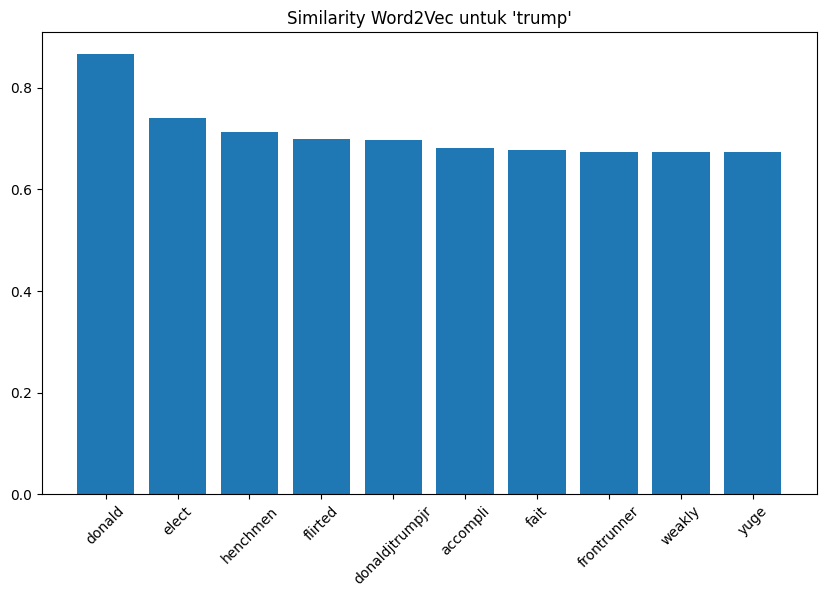

In [76]:
target_word = 'trump'

if target_word in model_w2v.wv:
    similar_words = model_w2v.wv.most_similar(target_word, topn=10)

    words = [word for word, score in similar_words]
    scores = [score for word, score in similar_words]

    print(f"Kata yang mirip dengan '{target_word}':")
    for word, score in similar_words:
        print(f"{word} : {score:.4f}")

    plt.figure(figsize=(10, 6))
    plt.bar(words, scores)
    plt.xticks(rotation=45)
    plt.title(f"Similarity Word2Vec untuk '{target_word}'")
    plt.show()

else:
    print(f"Kata '{target_word}' tidak ditemukan dalam vocabulary.")

(AUTO PILIH KATA)

In [ ]:
candidate_words = ['trump', 'government', 'media', 'president', 'news']

target_word = None
for word in candidate_words:
    if word in model_w2v.wv:
        target_word = word
        break

if target_word is not None:
    similar_words = model_w2v.wv.most_similar(target_word, topn=10)

    words = [word for word, score in similar_words]
    scores = [score for word, score in similar_words]

    plt.figure(figsize=(10, 6))
    plt.bar(words, scores)
    plt.xticks(rotation=45)
    plt.title(f"Kata yang Mirip dengan '{target_word}' (Word2Vec)")
    plt.show()

else:
    print("Tidak ada kata yang cocok di dalam vocabulary model.")

MENYIMPAN HASIL

In [ ]:
output_path = '/content/hasil_preprocessing_fake_word2vec.csv'

df_save = df.copy()
df_save['doc_vector'] = df_save['doc_vector'].apply(lambda x: x.tolist())

df_save.to_csv(output_path, index=False)
print("Hasil disimpan di:", output_path)

MENYIMPAN MODEL

In [79]:
model_path = '/content/model_word2vec_fake.model'
model_w2v.save(model_path)

print("Model disimpan di:", model_path)

Model disimpan di: /content/model_word2vec_fake.model


KESIMPULAN

In [80]:
print("Kesimpulan:")
print("1. Dataset Fake.csv berhasil diproses.")
print("2. Menggunakan gabungan title dan text.")
print("3. Preprocessing: cleaning, tokenization, stopword removal.")
print("4. Word2Vec digunakan sebagai representasi fitur.")
print("5. Model dan hasil berhasil disimpan.")

Kesimpulan:
1. Dataset Fake.csv berhasil diproses.
2. Menggunakan gabungan title dan text.
3. Preprocessing: cleaning, tokenization, stopword removal.
4. Word2Vec digunakan sebagai representasi fitur.
5. Model dan hasil berhasil disimpan.
